In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/data.csv")
print(df.shape)
df.head()

(75083, 11)


,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,0.01
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,0.02
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,0.02
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,0.02
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,0.02


In [3]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 75083 entries, 0 to 75082
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DATE              75083 non-null  str    
 1   VISIBILITY        75083 non-null  float64
 2   DRYBULBTEMPF      75083 non-null  int64  
 3   WETBULBTEMPF      75083 non-null  int64  
 4   DewPointTempF     75083 non-null  int64  
 5   RelativeHumidity  75083 non-null  int64  
 6   WindSpeed         75083 non-null  int64  
 7   WindDirection     75083 non-null  int64  
 8   StationPressure   75083 non-null  float64
 9   SeaLevelPressure  75083 non-null  float64
 10  Precip            75083 non-null  float64
dtypes: float64(4), int64(6), str(1)
memory usage: 6.3 MB


DATE                0
VISIBILITY          0
DRYBULBTEMPF        0
WETBULBTEMPF        0
DewPointTempF       0
RelativeHumidity    0
WindSpeed           0
WindDirection       0
StationPressure     0
SeaLevelPressure    0
Precip              0
dtype: int64

In [4]:
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d %H:%M:%S')

df['DATE'].head()

0   2010-01-01 00:51:00
1   2010-01-01 01:51:00
2   2010-01-01 02:51:00
3   2010-01-01 03:51:00
4   2010-01-01 04:51:00
Name: DATE, dtype: datetime64[us]

In [5]:
df['year'] = df['DATE'].dt.year
df['month'] = df['DATE'].dt.month
df['hour'] = df['DATE'].dt.hour

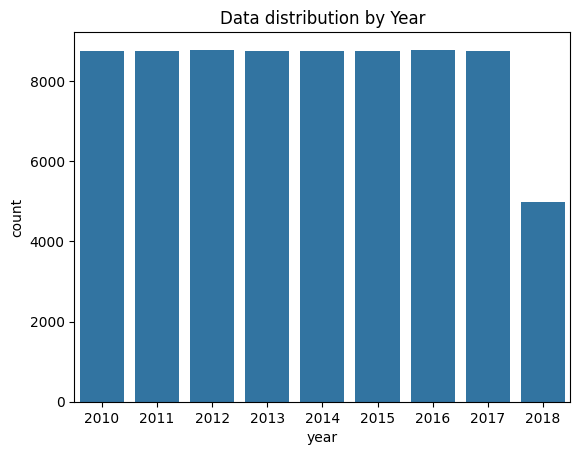

In [6]:
sns.countplot(x='year', data=df)
plt.title("Data distribution by Year")
plt.show()

In [7]:
columns = [col for col in df.columns if col != "VISIBILITY"]

numeric_features = [col for col in columns if df[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in columns if df[col].dtype == 'O']

print('Numerical Features:', numeric_features)
print('Categorical Features:', categorical_features)

Numerical Features: ['DRYBULBTEMPF', 'WETBULBTEMPF', 'DewPointTempF', 'RelativeHumidity', 'WindSpeed', 'WindDirection', 'StationPressure', 'SeaLevelPressure', 'Precip']
Categorical Features: []


Report:
Dataset contains only numerical features
No categorical features present
DATE handled separately as datetime feature
All features are suitable for ML models

Univariate Analysis

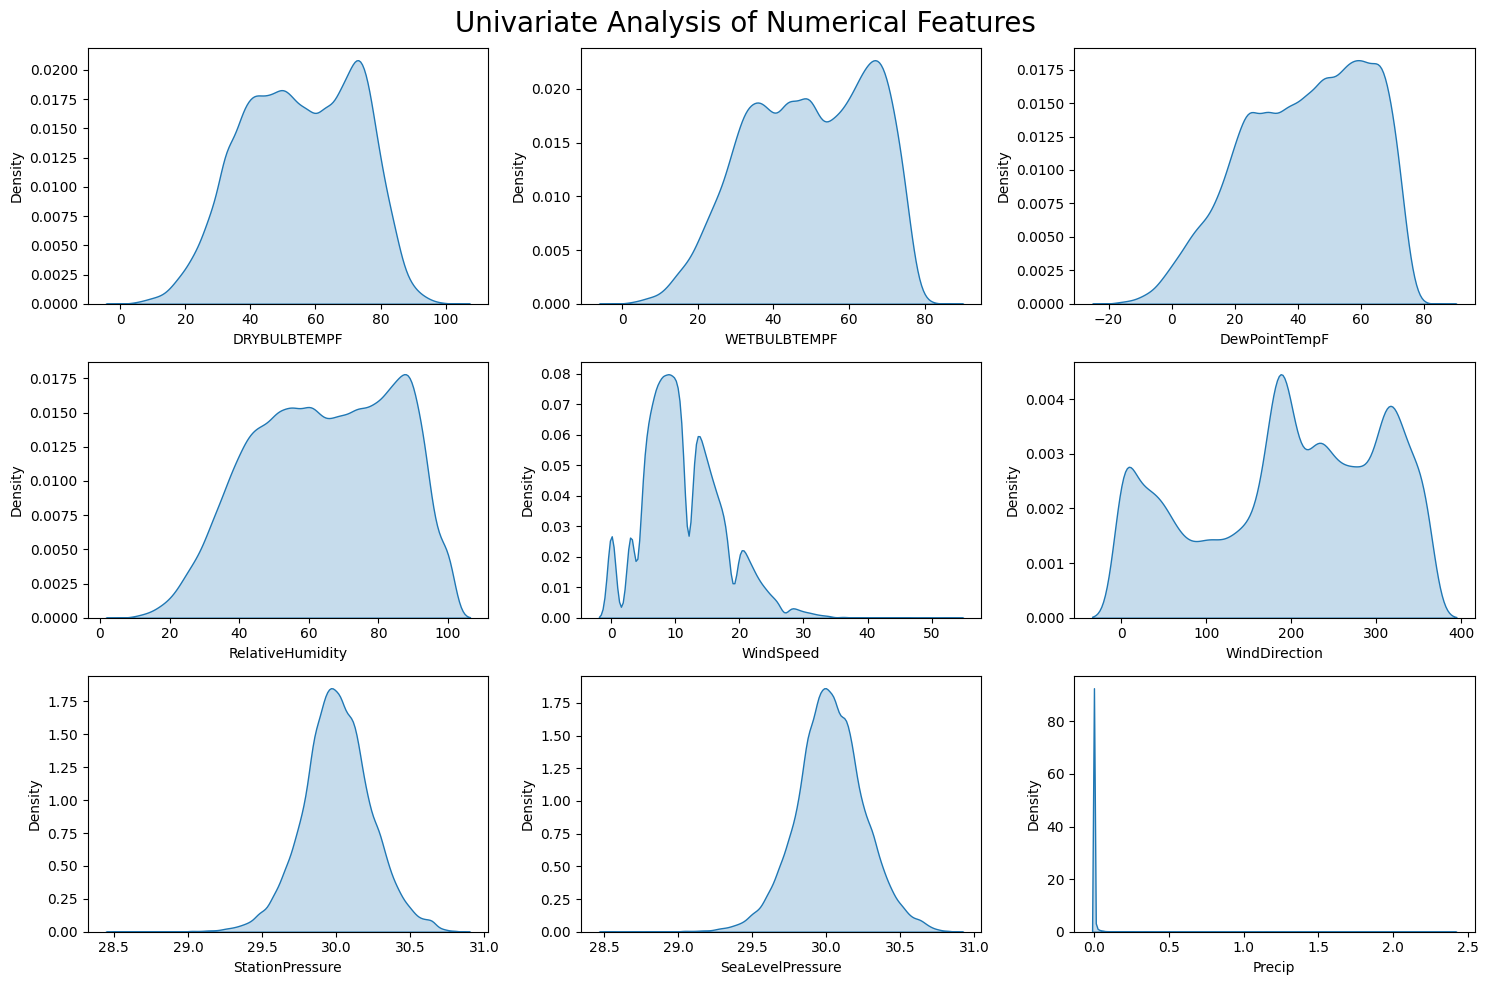

In [8]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20)

plot_features = ['DRYBULBTEMPF','WETBULBTEMPF','DewPointTempF',
                 'RelativeHumidity','WindSpeed','WindDirection',
                 'StationPressure','SeaLevelPressure','Precip']

for i, col in enumerate(plot_features):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(x=df[col], fill=True)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

Report:
DRYBULBTEMPF: Mostly between 25–100, slight skew
WETBULBTEMPF & DewPointTempF: Slightly left-skewed
RelativeHumidity: Concentrated between 40–100
WindSpeed: Right-skewed, presence of outliers
WindDirection: Widely distributed
Pressure columns: Near normal distribution
Precip: Highly skewed (mostly near 0)

Multivariate Analysis

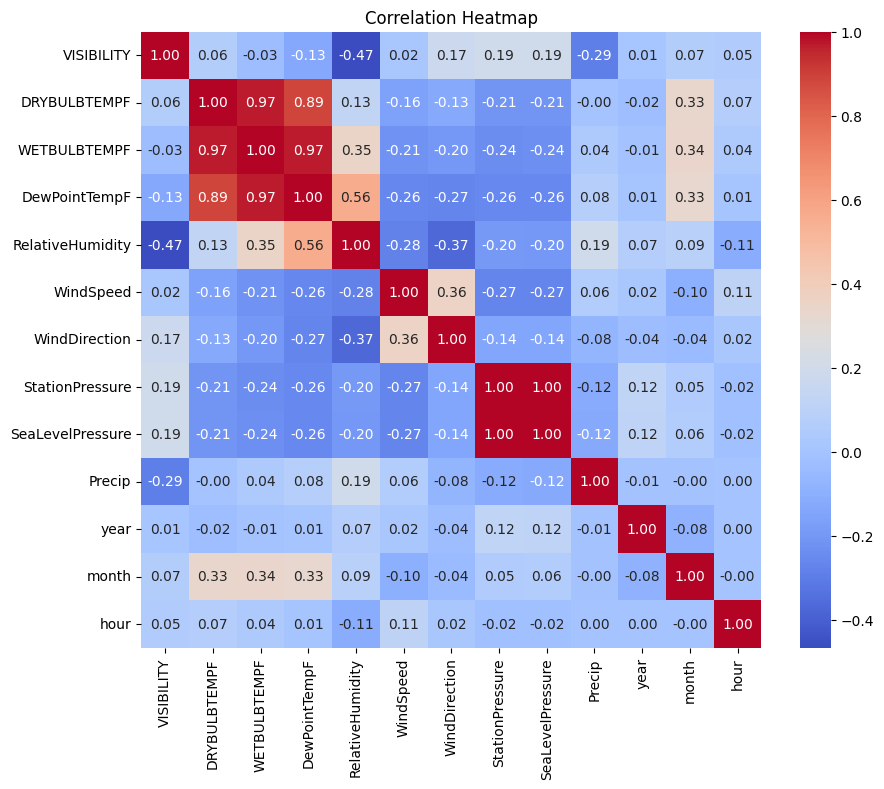

In [9]:
plt.figure(figsize=(10,8))

# drop DATE-related columns if still present
corr_df = df.drop(columns=['DATE'], errors='ignore')

sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Report:
Strong correlation observed between: WETBULBTEMPF & DewPointTempF & StationPressure & SeaLevelPressure
Moderate relationships exist among: Temperature-related features & Humidity-related features
VISIBILITY shows relationships with: RelativeHumidity & Temperature features

we need to drop ['WETBULBTEMPF','DewPointTempF','StationPressure']

In [10]:
#Mulcollirneary Check 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only feature columns (exclude target)
features = df.drop(columns=['VISIBILITY'], errors='ignore')

# Also remove DATE if still present
features = features.drop(columns=['DATE'], errors='ignore')

# Create dataframe for VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = features.columns
vif_data["VIF"] = [variance_inflation_factor(features.values, i) 
                   for i in range(features.shape[1])]

vif_data

,Feature,VIF
0,DRYBULBTEMPF,2.110091e+03
1,WETBULBTEMPF,2.619985e+03
2,DewPointTempF,1.025892e+03
3,RelativeHumidity,3.634482e+02
4,WindSpeed,6.077036e+00
5,WindDirection,5.712120e+00
6,StationPressure,3.193146e+06
7,SeaLevelPressure,3.248820e+06
8,Precip,1.097999e+00
9,year,2.507757e+04
